,id,league_id,season,stage,match_api_id,local,team_api_id,station,player_id,player_x,player_y
0,0,1,2008/2009,24,493017,away,9987,1,37937,1,1
1,1,1,2008/2009,24,493017,away,9987,2,38293,2,3
2,2,1,2008/2009,24,493017,away,9987,3,148313,4,3
3,3,1,2008/2009,24,493017,away,9987,4,104411,6,3
4,4,1,2008/2009,24,493017,away,9987,5,148314,8,3
...,...,...,...,...,...,...,...,...,...,...,...
469937,469937,24558,2015/2016,36,1992229,home,10243,7,632356,6,7
469938,469938,24558,2015/2016,36,1992229,home,10243,8,465399,8,7
469939,469939,24558,2015/2016,36,1992229,home,10243,9,462608,4,9
469940,469940,24558,2015/2016,36,1992229,home,10243,10,198082,6,9


<Axes: xlabel='season'>

<Axes: xlabel='season'>

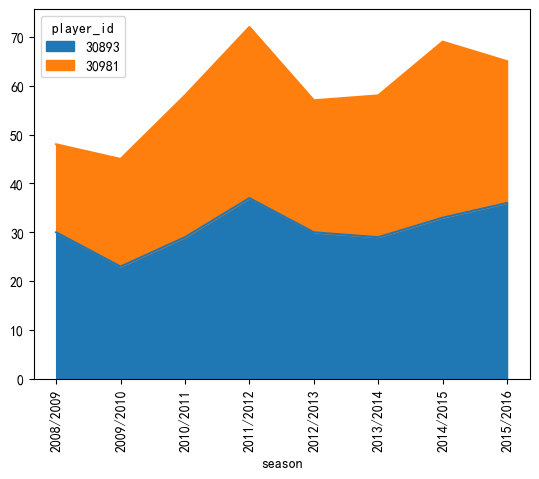

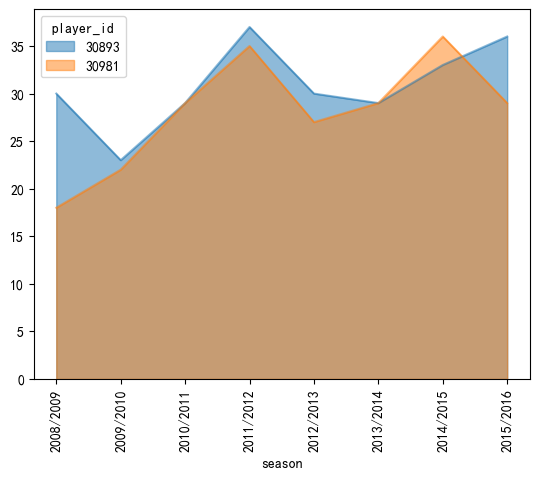

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('../data/match_team_player.csv')
df
df[df.player_id.isin([30981,30893])].groupby(['season','player_id'])['station'].count().unstack().plot.area(rot=90)
df[df.player_id.isin([30981,30893])].groupby(['season','player_id'])['station'].count().unstack().plot.area(stacked=False,rot=90)

<Axes: ylabel='count'>

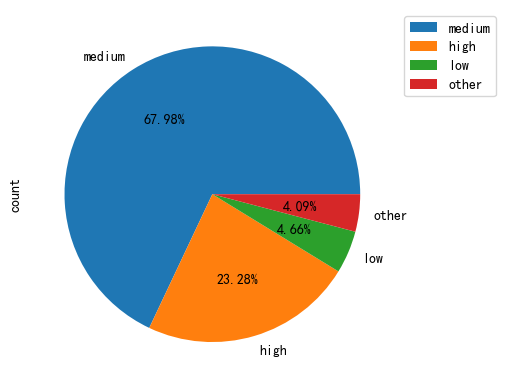

In [2]:
df = pd.read_csv('../data/player_attributes.csv')
df['new']=np.select([df.attacking_work_rate=='medium',df.attacking_work_rate=='high',df.attacking_work_rate=='low'],['medium','high','low'],'other')
df.new.value_counts().plot.pie(autopct='%.2f%%')
plt.legend(bbox_to_anchor=(1,1))

<Axes: xlabel='team_api_id'>

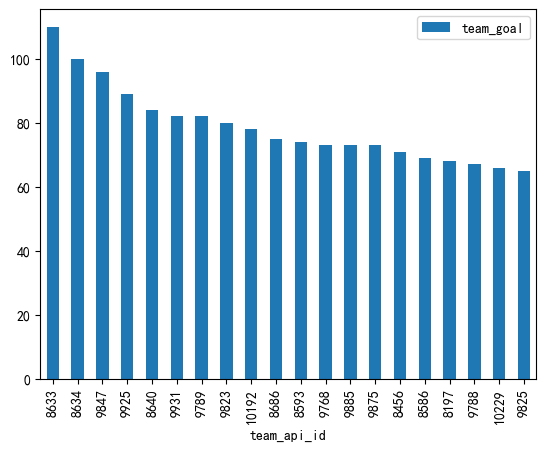

In [3]:
df=pd.read_csv('../data/match_goal.csv')
df.query('season=="2015/2016"').groupby('team_api_id')[['team_goal']].sum().sort_values(by='team_goal',ascending=False).iloc[:20].plot.bar()

<Axes: xlabel='overall_rating', ylabel='potential'>

,overall_rating,potential
player_api_id,,
2625,60.14,61.14
2752,69.38,70.38
2768,69.29,70.57
2770,71.13,73.53
2790,70.20,75.80
...,...,...
744907,51.91,65.91
746419,59.00,66.00
748432,58.00,68.00


<Axes: xlabel='overall_rating', ylabel='potential'>

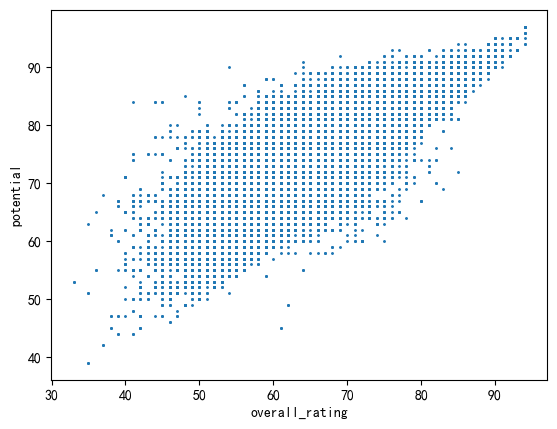

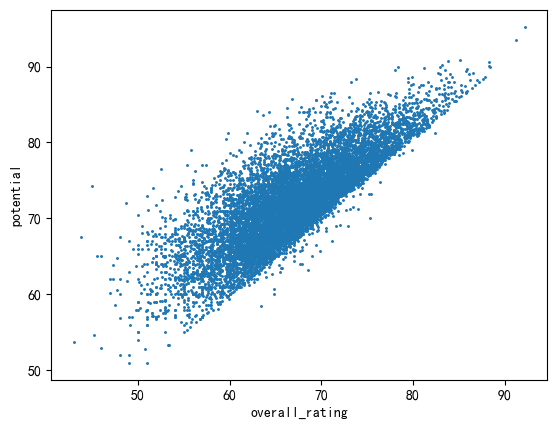

In [4]:
df = pd.read_csv('../data/player_attributes.csv')
df.plot.scatter(x='overall_rating',y='potential',s=1.2)
rating_mean = df.groupby(['player_api_id']).overall_rating.mean().round(2).to_frame()
potential_mean= df.groupby(['player_api_id']).potential.mean().round(2).to_frame()
df1 =pd.DataFrame({
    'overall_rating':rating_mean.overall_rating,
    'potential':potential_mean.potential
})
df1
df1.plot.scatter(x='overall_rating',y='potential',s=1.2)

team_goal    Axes(0.125,0.11;0.775x0.77)
dtype: object

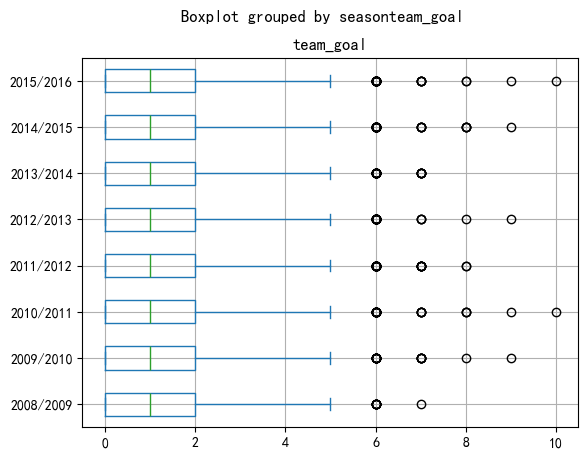

In [5]:
df=pd.read_csv('../data/match_goal.csv')
df.plot.box(by='season',column=['team_goal'],vert=False,title='Boxplot grouped by seasonteam_goal',grid=True)

<Axes: ylabel='Frequency'>

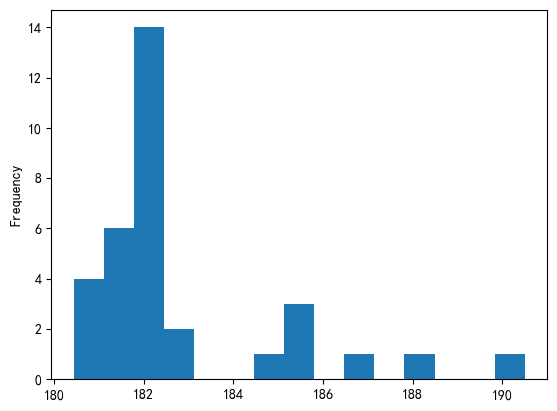

<Axes: ylabel='Density'>

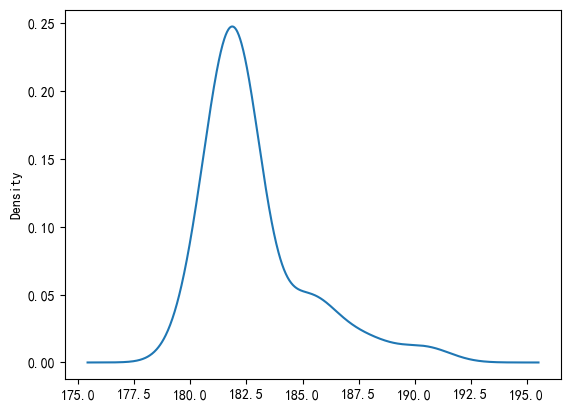

'======================================================================================================================================================================================================'

<Axes: ylabel='Frequency'>

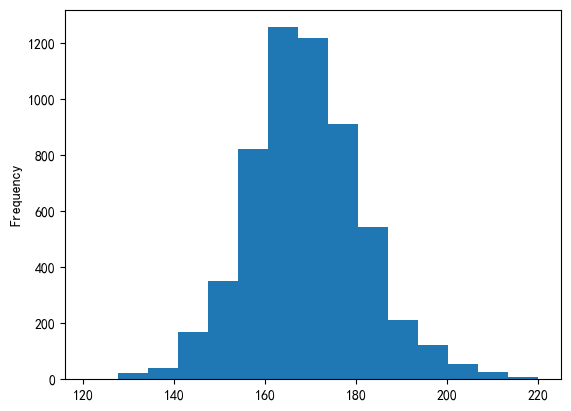

<Axes: ylabel='Density'>

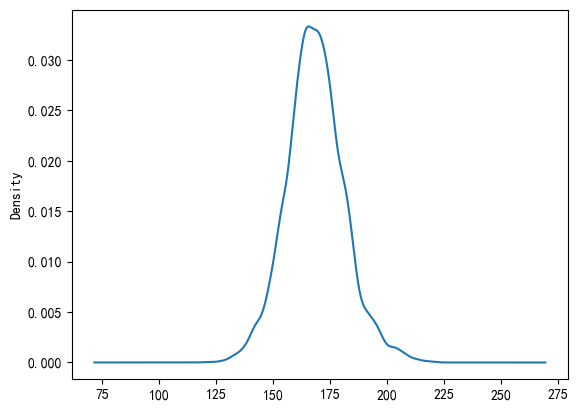

'======================================================================================================================================================================================================'

<Axes: ylabel='Frequency'>

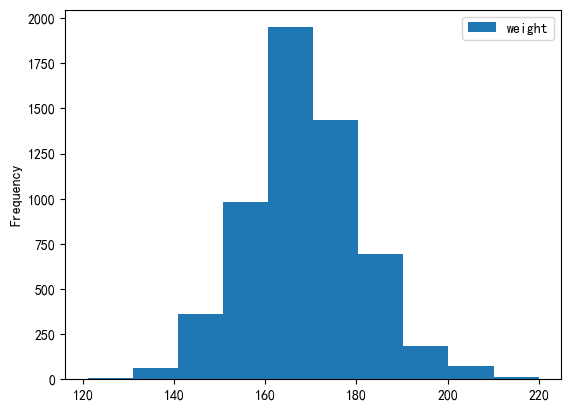

<Axes: ylabel='Frequency'>

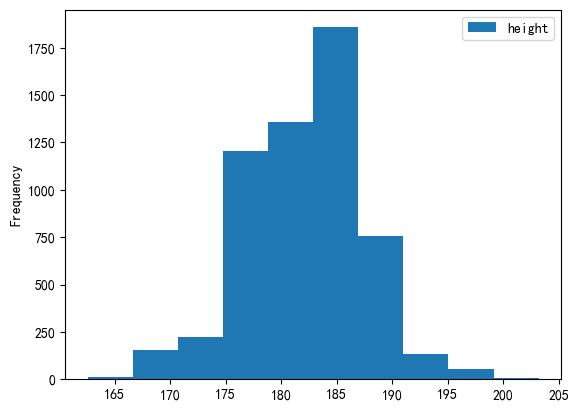

<Axes: ylabel='Frequency'>

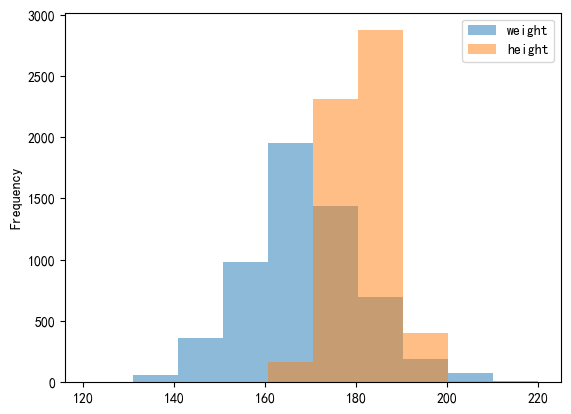

<Axes: ylabel='Count'>

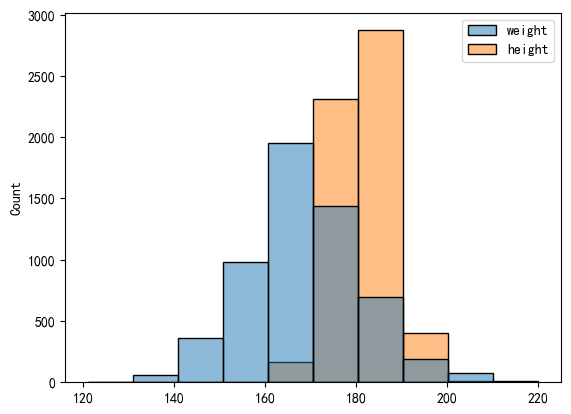

In [9]:
df=pd.read_csv('../data/player.csv')
# from seaborn import histplot
# histplot(df.groupby('birthday').height.mean(),bins = 20,kde=True)
df.birthday = pd.to_datetime(df.birthday).dt.year
df.groupby('birthday').height.mean().plot.hist(bins = 15,grid=False)
plt.show()
df.groupby('birthday').height.mean().plot.kde()
plt.show()
'=='*99
df=pd.read_csv('../data/player.csv')
df.groupby('birthday').weight.mean().plot.hist(bins = 15,grid=False)
plt.show()
df.groupby('birthday').weight.mean().plot.kde()
plt.show()
'=='*99
df.groupby('birthday')[['weight']].mean().plot.hist()
plt.show()
df.groupby('birthday')[['height']].mean().plot.hist()
plt.show()
df.groupby('birthday')[['weight','height']].mean().plot.hist(bins=10,alpha = 0.5)
plt.show()
from seaborn import histplot
histplot(df.groupby('birthday')[['weight','height']].mean(),bins =10)

<Axes: xlabel='height', ylabel='Count'>

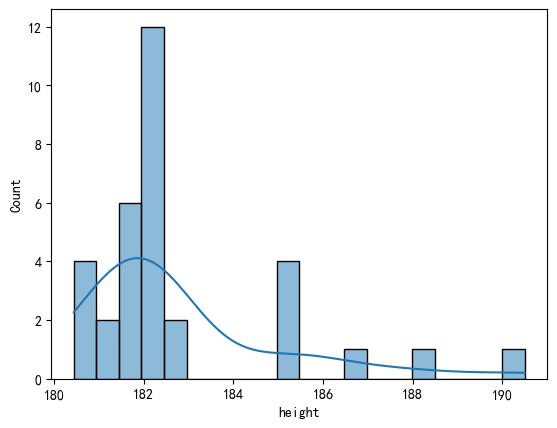

<Axes: xlabel='weight', ylabel='Count'>

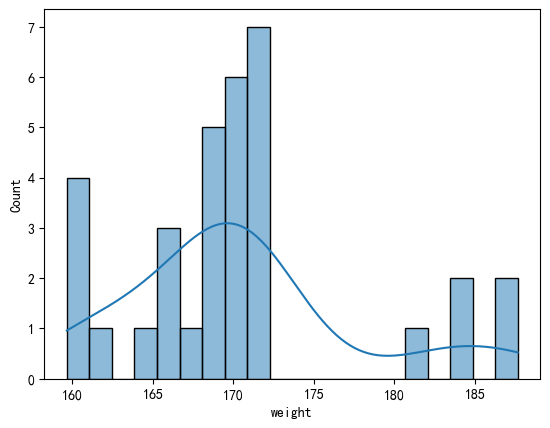

<Axes: ylabel='Count'>

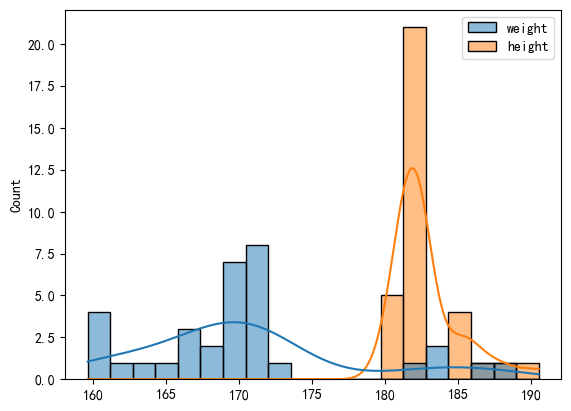

In [10]:
df=pd.read_csv('../data/player.csv')
df.birthday = pd.to_datetime(df.birthday).dt.year
histplot(df.groupby('birthday').height.mean(),bins=20,kde=True)
plt.show()
histplot(df.groupby('birthday').weight.mean(),bins=20,kde=True)
plt.show()
histplot(df.groupby('birthday')[['weight','height']].mean(),bins=20,kde=True)

<Axes: >

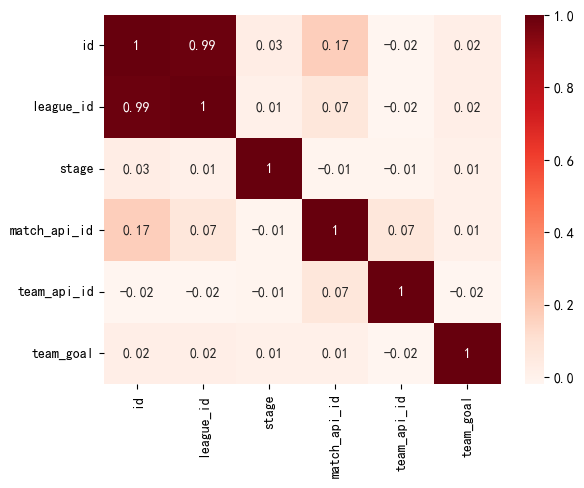

In [11]:
# 获取球队全部数值数据
from seaborn import heatmap
df=pd.read_csv('../data/match_goal.csv')
df1=df.select_dtypes('number')
heatmap(df1.corr().round(2),cmap='Reds',annot=True)
plt.show()

<Axes: xlabel='overall_rating'>

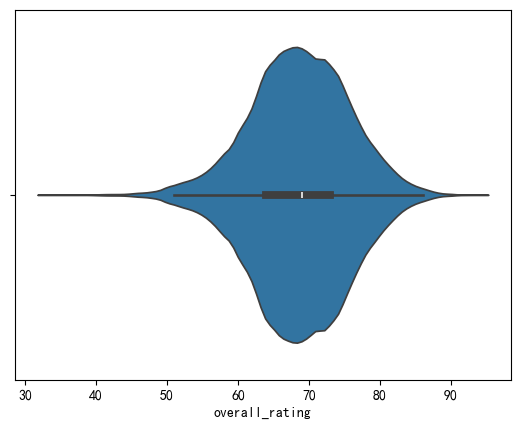

<Axes: xlabel='potential'>

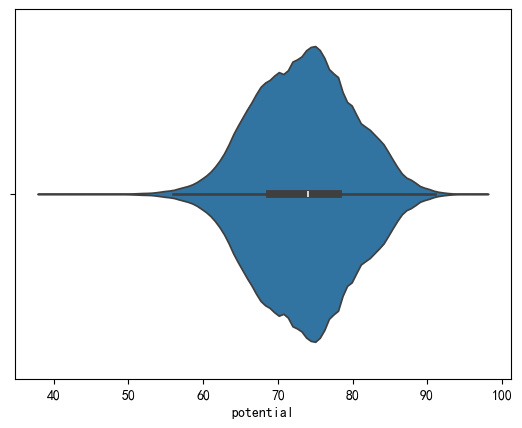

<Axes: xlabel='overall_rating', ylabel='preferred_foot'>

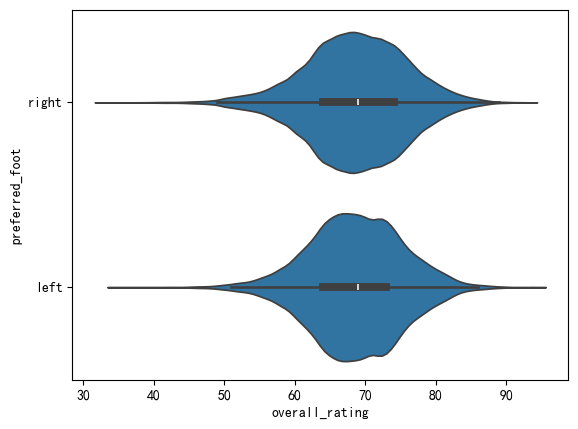

<Axes: xlabel='overall_rating', ylabel='preferred_foot'>

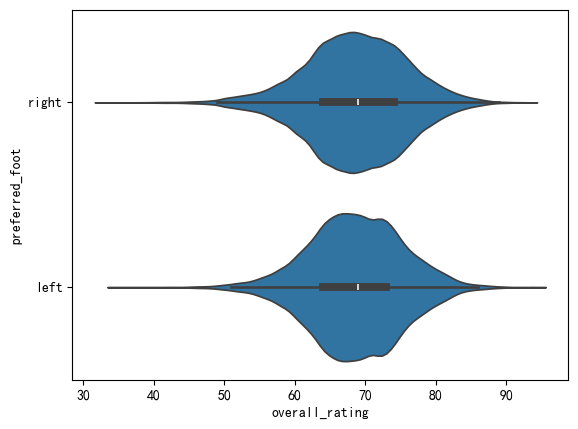

In [15]:
# 加载球员评价数据
# 设置惯用脚preferred_foot为索引
# 绘制整体评分overall rating和潜力值potential的小提琴图
# 根据惯用脚分类，绘制评分与潜能的小提琴图
df = pd.read_csv('../data/player_attributes.csv')
df1=df.set_index('preferred_foot',append=True).swaplevel(0,1)
from seaborn import violinplot
violinplot(df1.overall_rating,orient='h')
plt.show()
violinplot(df1.potential,orient='h')
plt.show()
violinplot(x=df.overall_rating,y=df.preferred_foot,orient='h')
plt.show()
violinplot(x=df.overall_rating,y=df.preferred_foot,orient='h')
plt.show()